In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw_metadata.csv")

df.head()

,video_id,title,published_date
0,UsfpzxZNsPo,Python Essentials for AI Agents – Tutorial,2026-02-25T11:00:52Z
1,U6-RekkuORI,Closures in JavaScript explained with a simple...,2026-02-24T13:05:28Z
2,bB5eA7vU9W8,Learn Notion – Full Course for Beginners,2026-02-24T11:00:57Z
3,Ai00MsNabaE,True or false: computers only understand 1s an...,2026-02-23T13:17:29Z
4,QMgIovzpYVw,"When you're working, work hard. And when you r...",2026-02-22T13:43:36Z


In [3]:
print("Dataset shape:", df.shape)

Dataset shape: (2131, 3)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2131 entries, 0 to 2130
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   video_id        2131 non-null   str  
 1   title           2131 non-null   str  
 2   published_date  2131 non-null   str  
dtypes: str(3)
memory usage: 50.1 KB


In [5]:
df.columns

Index(['video_id', 'title', 'published_date'], dtype='str')

In [6]:
print("Duplicate video_ids:", df["video_id"].duplicated().sum())
print("Duplicate titles:", df["title"].duplicated().sum())

Duplicate video_ids: 0
Duplicate titles: 7


In [7]:
df["published_date"] = pd.to_datetime(df["published_date"])

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2131 entries, 0 to 2130
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   video_id        2131 non-null   str                
 1   title           2131 non-null   str                
 2   published_date  2131 non-null   datetime64[us, UTC]
dtypes: datetime64[us, UTC](1), str(2)
memory usage: 50.1 KB


In [9]:
df["year"] = df["published_date"].dt.year
df["month"] = df["published_date"].dt.month

In [10]:
df.head()

,video_id,title,published_date,year,month
0,UsfpzxZNsPo,Python Essentials for AI Agents – Tutorial,2026-02-25 11:00:52+00:00,2026,2
1,U6-RekkuORI,Closures in JavaScript explained with a simple...,2026-02-24 13:05:28+00:00,2026,2
2,bB5eA7vU9W8,Learn Notion – Full Course for Beginners,2026-02-24 11:00:57+00:00,2026,2
3,Ai00MsNabaE,True or false: computers only understand 1s an...,2026-02-23 13:17:29+00:00,2026,2
4,QMgIovzpYVw,"When you're working, work hard. And when you r...",2026-02-22 13:43:36+00:00,2026,2


In [11]:
videos_per_year = df["year"].value_counts().sort_index()

videos_per_year

year
2015     45
2016     42
2017    296
2018    395
2019    142
2020    166
2021    155
2022    141
2023    180
2024    224
2025    264
2026     81
Name: count, dtype: int64

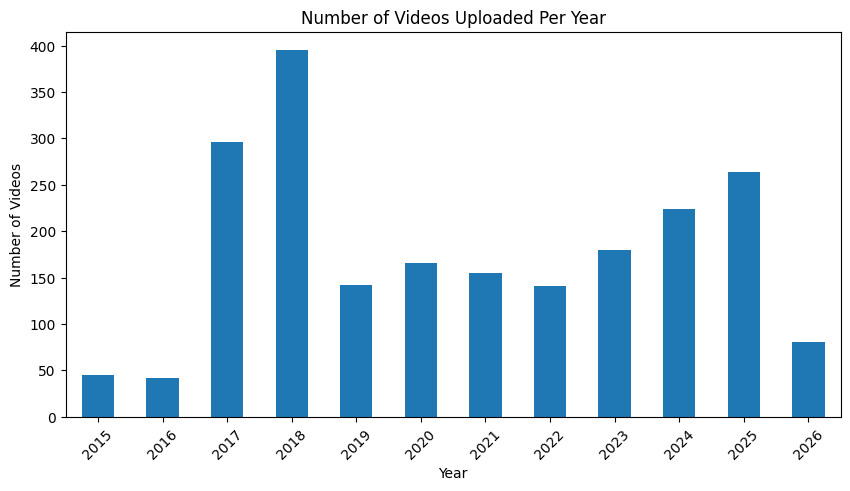

In [12]:
plt.figure(figsize=(10,5))
videos_per_year.plot(kind="bar")

plt.title("Number of Videos Uploaded Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Videos")
plt.xticks(rotation=45)
plt.show()

The channel experienced rapid growth in uploads between 2017 and 2018, with 2018 showing the highest number of uploads. After 2019, the upload frequency stabilized with moderate fluctuations. The current year shows fewer uploads, likely because the year is still ongoing.

In [13]:
videos_per_month = df["month"].value_counts().sort_index()

videos_per_month

month
1     180
2     181
3     164
4     137
5     175
6     171
7     205
8     192
9     224
10    180
11    176
12    146
Name: count, dtype: int64

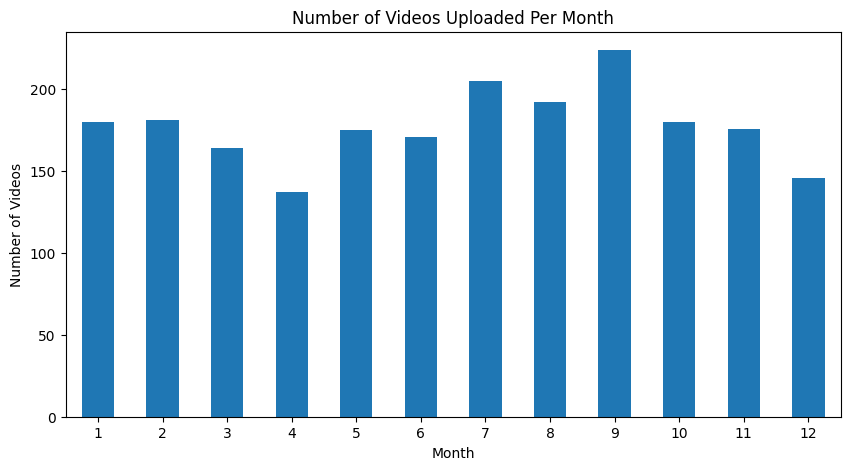

In [14]:
plt.figure(figsize=(10,5))
videos_per_month.plot(kind="bar")

plt.title("Number of Videos Uploaded Per Month")
plt.xlabel("Month")
plt.ylabel("Number of Videos")
plt.xticks(rotation=0)
plt.show()

The monthly upload distribution shows that the channel uploads content consistently throughout the year. September appears to have the highest number of uploads, while April has relatively fewer uploads. Overall, there is no strong seasonal dependency, indicating steady content production.

In [15]:
df["title_length"] = df["title"].apply(len)

df["title_length"].describe()

count    2131.000000
mean       56.743782
std        18.364797
min        12.000000
25%        44.000000
50%        56.000000
75%        69.000000
max       100.000000
Name: title_length, dtype: float64

Total videos analyzed: 2131

Average title length: ~57 characters

Shortest title: 12 characters

Longest title: 100 characters

Most titles fall between 44 and 69 characters

Distribution looks reasonably balanced (std ≈ 18)

In [16]:
# Shortest title
df.loc[df["title_length"].idxmin(), ["title", "title_length"]]

title           Is that him?
title_length              12
Name: 445, dtype: object

In [17]:
# Longest title
df.loc[df["title_length"].idxmax(), ["title", "title_length"]]

title           When NOT to use AI in your hackathon project w...
title_length                                                  100
Name: 137, dtype: object

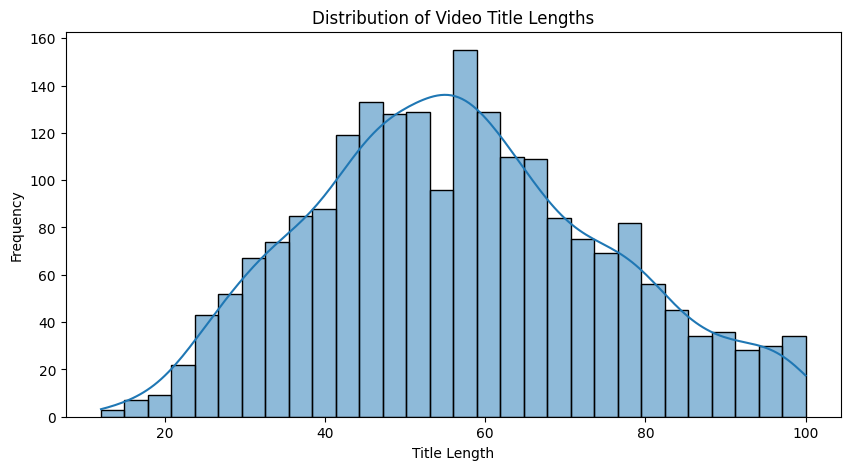

In [18]:
plt.figure(figsize=(10,5))
sns.histplot(df["title_length"], bins=30, kde=True)

plt.title("Distribution of Video Title Lengths")
plt.xlabel("Title Length")
plt.ylabel("Frequency")
plt.show()

The distribution of title lengths follows an approximately normal distribution. Most titles fall between 40 and 70 characters, with an average length of approximately 57 characters. Extremely short and extremely long titles are relatively rare, indicating consistent title formatting across the channel.

In [19]:
print("Total unique videos:", df["video_id"].nunique())
print("Date range:", df["published_date"].min(), "to", df["published_date"].max())

Total unique videos: 2131
Date range: 2015-07-17 08:31:10+00:00 to 2026-02-25 11:00:52+00:00


In [20]:
df_sorted = df.sort_values(by="published_date", ascending=False)

df_limited = df_sorted.head(300)

print("Limited dataset size:", df_limited.shape)

Limited dataset size: (300, 6)


In [21]:
df_limited["video_id"].nunique()

300

In [22]:
df_limited["title"] = df_limited["title"].str.strip()
df_limited["title"] = df_limited["title"].str.replace("\n", " ", regex=True)

In [23]:
df_limited["title"].head()

0           Python Essentials for AI Agents – Tutorial
1    Closures in JavaScript explained with a simple...
2             Learn Notion – Full Course for Beginners
3    True or false: computers only understand 1s an...
4    When you're working, work hard. And when you r...
Name: title, dtype: str

In [24]:
df_limited.to_csv("../data/cleaned_metadata.csv", index=False)

print("cleaned_metadata.csv saved successfully")

cleaned_metadata.csv saved successfully
